# LAB-D4-02 Instructor Solution: Model Detective - Curves and Error Buckets

**Purpose:** Diagnose unlabeled learning evidence, then turn aligned prediction failures into a prioritized and falsifiable next experiment.

**Objectives:** `OBJ-D4-02`, `OBJ-D4-03`  
**Estimated duration:** 40 minutes live; core CPU analysis under 30 seconds  
**Prerequisites:** [LESSON-D4-02](../../day-4/student-guide/day-4-student-guide.md#lesson-d4-02---read-curves-as-competing-hypotheses), [LESSON-D4-03](../../day-4/student-guide/day-4-student-guide.md#lesson-d4-03---error-analysis-turns-an-average-into-a-work-queue), [ACT-D4-02](../../day-4/challenges/day-4-challenges.md#act-d4-02---mystery-curves), and Day 3 curve evidence  
**Environment:** CPU; NumPy, matplotlib, scikit-learn; packaged fixed artifacts; no network or training required

Workflow: **Observe anonymous curves -> Predict -> Cite two observations -> Inspect aggregate -> Drill into errors -> Define slices -> Quantify prevalence/severity/payoff -> Propose one disconfirming experiment**.

In [1]:
import hashlib
import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.metrics import confusion_matrix

started = time.perf_counter()
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.2})

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "courseware/shared/data/day-4/manifest.json").exists(): return candidate
    raise FileNotFoundError("Run from the repository checkout with courseware/shared/data/day-4 present.")

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""): digest.update(chunk)
    return digest.hexdigest()

ROOT = find_repo_root(); DATA_DIR = ROOT / "courseware/shared/data/day-4"
manifest = json.loads((DATA_DIR / "manifest.json").read_text())
print(f"Python {platform.python_version()} | NumPy {np.__version__} | scikit-learn {sklearn.__version__}")

Python 3.11.8 | NumPy 2.4.6 | scikit-learn 1.9.0


## Local Artifact Contract

The four curve bundles are deterministic and unlabeled. The digits artifact contains aligned validation sample IDs, images, labels, probabilities, predictions, confidence, and label-blind image metadata. It contains no model configuration, diagnosis, bucket answer, or test evidence.

In [2]:
for key in ["mystery_curves", "digits_evidence"]:
    record = manifest["artifacts"][key]
    path = DATA_DIR / record["path"]
    assert path.is_file() and file_sha256(path) == record["sha256"]
curves = np.load(DATA_DIR / manifest["artifacts"]["mystery_curves"]["path"], allow_pickle=False)
evidence = np.load(DATA_DIR / manifest["artifacts"]["digits_evidence"]["path"], allow_pickle=False)
print("Verified artifact checksums and aligned arrays.")

Verified artifact checksums and aligned arrays.


## Observe Anonymous Curves

All bundles use the same neutral colors and axes. Configuration names are intentionally absent. Diagnose from relationships, not styling.

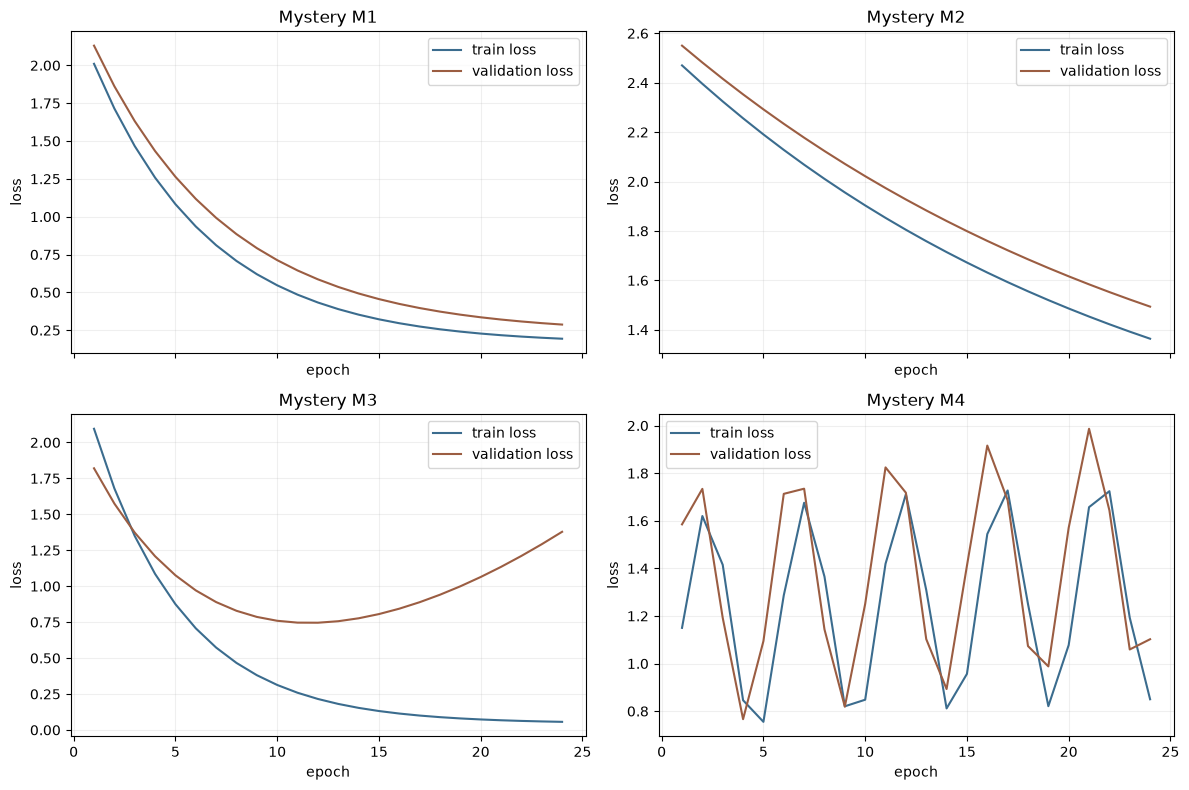

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for bundle_index, (bundle_id, ax) in enumerate(zip(curves["bundle_ids"], axes.ravel())):
    ax.plot(curves["epochs"], curves["train_loss"][bundle_index], color="#3b6c8e", label="train loss")
    ax.plot(curves["epochs"], curves["val_loss"][bundle_index], color="#9b5d42", label="validation loss")
    ax.set(title=f"Mystery {bundle_id}", xlabel="epoch", ylabel="loss"); ax.legend()
plt.tight_layout(); plt.show()

## Predict Before Labels

For each bundle, record a leading pattern, two curve observations, one competing explanation, and one evidence request. Use the vocabulary healthy fit, limited fit, widening generalization gap, and unstable/stalled optimization only as hypotheses, not unique causes.

In [4]:
curve_diagnoses = {
    "M1": {"leading_pattern": "healthy fit", "observation_one": "train and validation loss fall together", "observation_two": "accuracy rises with a modest gap", "alternative": "an important slice may still fail", "requested_evidence": "class and slice metrics"},
    "M2": {"leading_pattern": "limited fit", "observation_one": "both losses remain high", "observation_two": "both accuracies plateau low", "alternative": "features may be weak", "requested_evidence": "capacity-controlled comparison"},
    "M3": {"leading_pattern": "widening generalization gap", "observation_one": "training loss keeps falling", "observation_two": "validation loss reverses upward", "alternative": "split shift could mimic the gap", "requested_evidence": "split and slice audit"},
    "M4": {"leading_pattern": "unstable optimization", "observation_one": "losses oscillate strongly", "observation_two": "accuracy also jumps", "alternative": "a corrupted batch could cause spikes", "requested_evidence": "learning rate and gradient traces"},
}
assert all(all(value.strip() for value in response.values()) for response in curve_diagnoses.values())

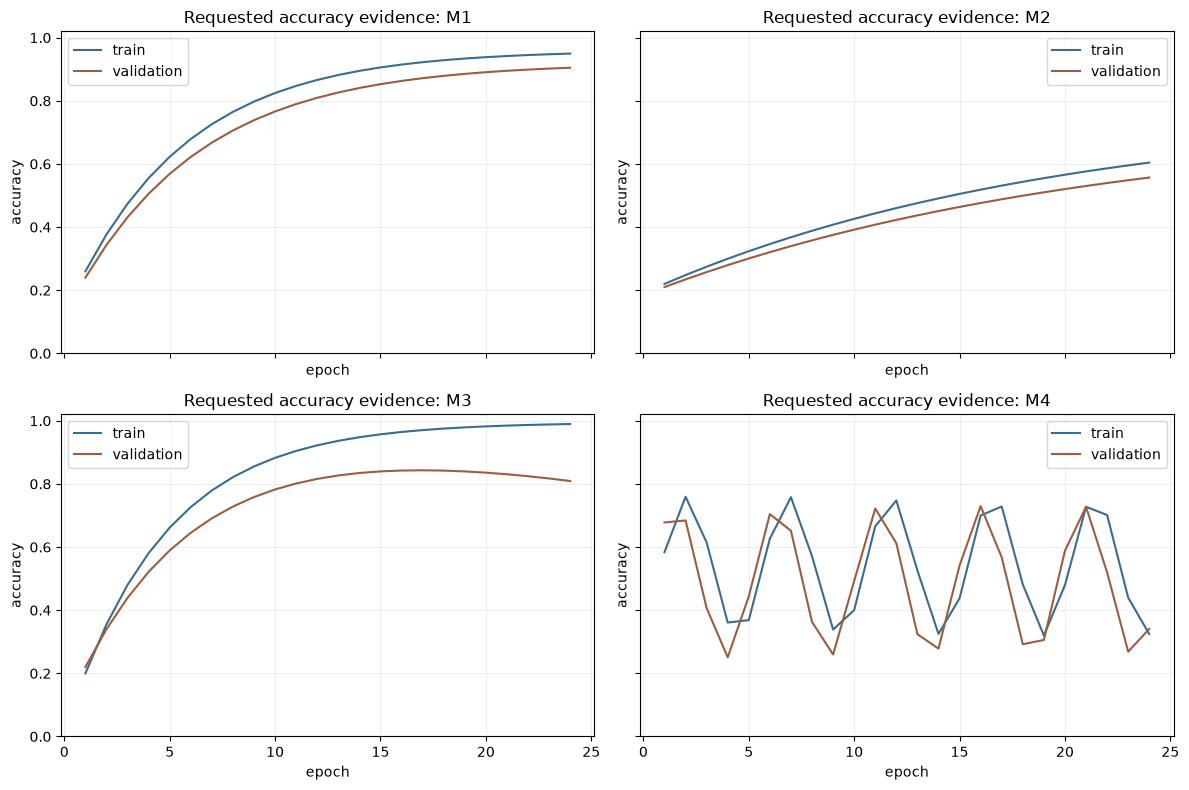

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for bundle_index, (bundle_id, ax) in enumerate(zip(curves["bundle_ids"], axes.ravel())):
    ax.plot(curves["epochs"], curves["train_accuracy"][bundle_index], color="#3b6c8e", label="train")
    ax.plot(curves["epochs"], curves["val_accuracy"][bundle_index], color="#9b5d42", label="validation")
    ax.set(title=f"Requested accuracy evidence: {bundle_id}", xlabel="epoch", ylabel="accuracy", ylim=(0,1.02)); ax.legend()
plt.tight_layout(); plt.show()

## Aggregate Digits Baseline

Treat each 8x8 image as a routing-code glyph. First verify alignment, then inspect accuracy and the complete `(10,10)` confusion matrix.

In [6]:
sample_ids = evidence["sample_ids"]
images, labels = evidence["images"], evidence["labels"]
probabilities, predictions, confidence = evidence["probabilities"], evidence["predictions"], evidence["confidence"]
assert images.shape[0] == labels.shape[0] == probabilities.shape[0] == len(sample_ids)
assert probabilities.shape[1] == 10 and np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5)
accuracy = float(np.mean(predictions == labels))
confusion = confusion_matrix(labels, predictions, labels=np.arange(10))
assert 0.90 <= accuracy <= 0.96 and confusion.shape == (10, 10)
print(f"Fixed validation accuracy: {accuracy:.3f}; errors: {np.sum(predictions != labels)}")

Fixed validation accuracy: 0.953; errors: 17


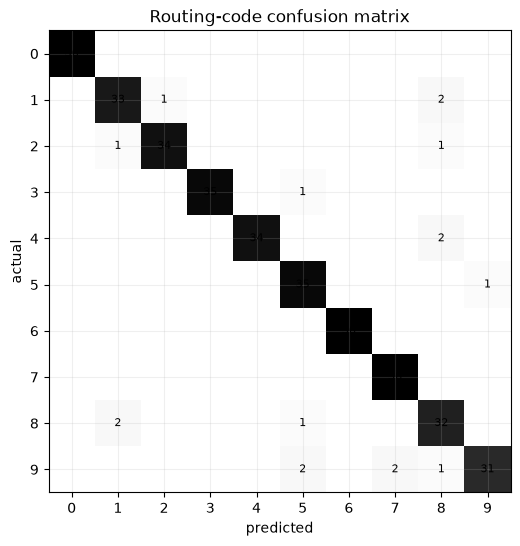

Top directed confusion pairs: [(9, 7, 2), (4, 8, 2), (9, 5, 2), (1, 8, 2), (8, 1, 2)]


In [7]:
fig, ax = plt.subplots(figsize=(7, 6)); ax.imshow(confusion, cmap="Greys")
for (row, col), value in np.ndenumerate(confusion):
    if value: ax.text(col, row, str(value), ha="center", va="center", fontsize=8)
ax.set(title="Routing-code confusion matrix", xlabel="predicted", ylabel="actual", xticks=range(10), yticks=range(10)); plt.show()
pair_counts = confusion.copy(); np.fill_diagonal(pair_counts, 0)
top_pairs = np.dstack(np.unravel_index(np.argsort(pair_counts.ravel())[::-1][:5], pair_counts.shape))[0]
print("Top directed confusion pairs:", [(int(a), int(b), int(pair_counts[a,b])) for a,b in top_pairs])

## Predict Before the Error Gallery

Choose two likely high-value error categories from confusion counts alone. Then state why selected images cannot substitute for prevalence counts.

In [8]:
gallery_predictions = {
    "two_candidate_categories": "high-confidence errors and low-ink examples",
    "likely_high_cost_pair": "A frequent directed class confusion with high consequence weight.",
    "why_gallery_is_not_prevalence": "The gallery is confidence-ranked, so selected examples do not estimate population frequency.",
}
assert all(value.strip() for value in gallery_predictions.values())

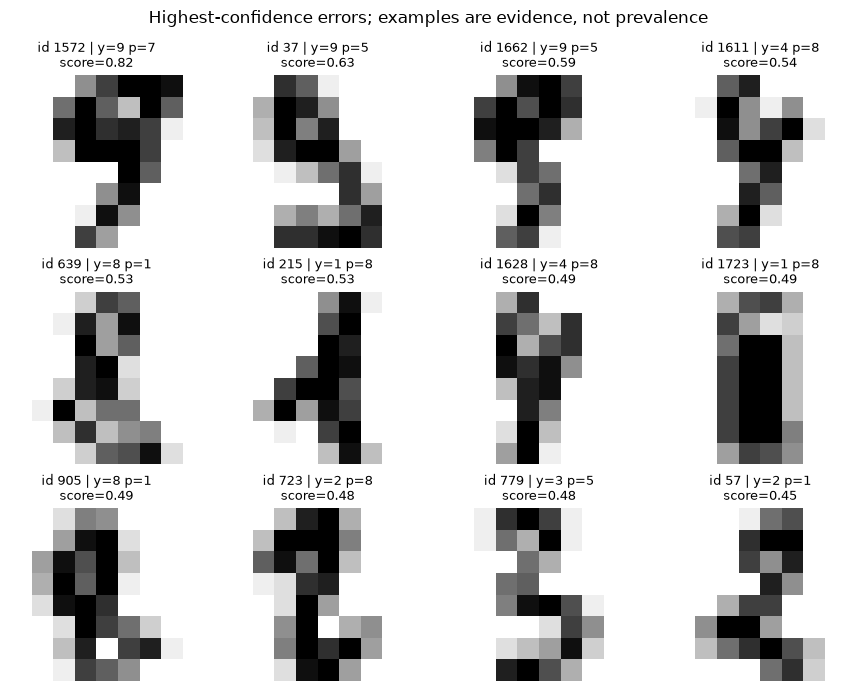

In [9]:
error_indices = np.flatnonzero(predictions != labels)
ranked_errors = error_indices[np.argsort(confidence[error_indices])[::-1]]
gallery_indices = ranked_errors[:12]
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for index, ax in zip(gallery_indices, axes.ravel()):
    ax.imshow(images[index], cmap="gray_r")
    ax.set_title(f"id {sample_ids[index]} | y={labels[index]} p={predictions[index]}\nscore={confidence[index]:.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("Highest-confidence errors; examples are evidence, not prevalence")
plt.tight_layout(); plt.show()
assert len(gallery_indices) > 0

## Focused TODO: Two Reproducible Slices

Define at least two boolean masks from supplied metadata. Suggested starting points are high border ink and low total ink; thresholds must be computed from the fixed artifact, not chosen after reading labels. Masks may overlap, but report overlap explicitly.

In [10]:
slice_masks = {
    "high_border_ink": evidence["border_ink"] >= np.quantile(evidence["border_ink"], 0.75),
    "low_total_ink": evidence["ink_total"] <= np.quantile(evidence["ink_total"], 0.25),
}
assert all(isinstance(mask, np.ndarray) and mask.dtype == bool and mask.shape == labels.shape for mask in slice_masks.values())

In [11]:
def slice_row(name, mask, severity_weight):
    count = int(mask.sum()); errors = int(np.sum(mask & (predictions != labels)))
    return {
        "slice": name, "count": count, "prevalence": count / len(labels), "errors": errors,
        "error_rate": errors / max(count, 1), "severity_weight": severity_weight,
        "payoff_proxy": errors * severity_weight,
    }

severity_weights = {"high_border_ink": 2.0, "low_total_ink": 1.0}
slice_table = [slice_row(name, mask, severity_weights[name]) for name, mask in slice_masks.items()]
overlap = int(np.logical_and.reduce(list(slice_masks.values())).sum())
for row in slice_table: print(row)
print("Slice overlap:", overlap)
assert all(row["count"] > 0 for row in slice_table)

{'slice': 'high_border_ink', 'count': 93, 'prevalence': 0.2590529247910863, 'errors': 6, 'error_rate': 0.06451612903225806, 'severity_weight': 2.0, 'payoff_proxy': 12.0}
{'slice': 'low_total_ink', 'count': 90, 'prevalence': 0.25069637883008355, 'errors': 8, 'error_rate': 0.08888888888888889, 'severity_weight': 1.0, 'payoff_proxy': 8.0}
Slice overlap: 18


## Build Error Buckets Without Double Counting

Assign every error to one primary bucket using a declared precedence. The starter precedence is: high-confidence -> high-border -> low-ink -> other. You may rename categories after inspecting images, but do not encode a diagnosis in the artifact itself.

In [12]:
primary_bucket = np.full(len(labels), "not_error", dtype=object)
remaining = predictions != labels
for name, mask in [
    ("high_confidence", confidence >= 0.60),
    ("high_border_ink", slice_masks["high_border_ink"]),
    ("low_total_ink", slice_masks["low_total_ink"]),
]:
    assigned = remaining & mask
    primary_bucket[assigned] = name
    remaining &= ~assigned
primary_bucket[remaining] = "other_error"
bucket_names, bucket_counts = np.unique(primary_bucket[predictions != labels], return_counts=True)
assert bucket_counts.sum() == len(error_indices)
print("Exclusive error buckets:", dict(zip(bucket_names, bucket_counts)))

Exclusive error buckets: {'high_border_ink': np.int64(4), 'high_confidence': np.int64(2), 'low_total_ink': np.int64(7), 'other_error': np.int64(4)}


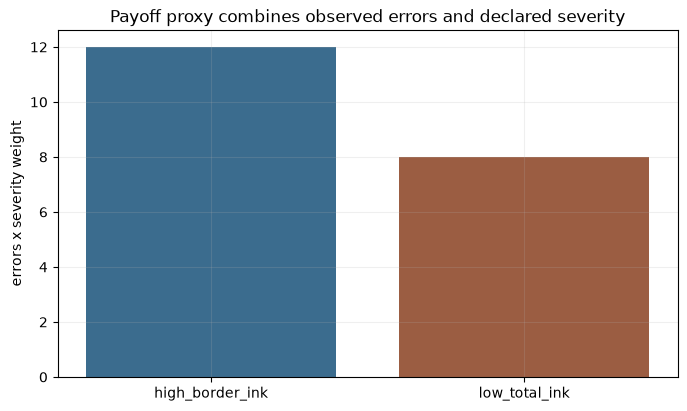

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
payoff_names = [row["slice"] for row in slice_table]
payoff_values = [row["payoff_proxy"] for row in slice_table]
ax.bar(payoff_names, payoff_values, color=["#3b6c8e", "#9b5d42"])
ax.set(title="Payoff proxy combines observed errors and declared severity", ylabel="errors x severity weight")
plt.show()

## Prioritize One Next Experiment

Frequency, severity, fixability, and spillover can disagree. State one experiment and the evidence that would disconfirm its mechanism. Do not propose several simultaneous changes.

In [14]:
next_experiment = {
    "priority_bucket": "high-border-ink errors",
    "prevalence_evidence": "Use the declared slice count and error rate, not the selected gallery.",
    "severity_assumption": "A border-related routing error receives weight 2 in this classroom proxy.",
    "single_intervention": "Apply one fixed border-normalization preprocessing change.",
    "predicted_observation": "The high-border slice error rate falls without material aggregate regression.",
    "disconfirming_evidence": "The slice error rate is unchanged or another slice worsens beyond tolerance.",
    "competing_explanation": "The same errors may be label ambiguity rather than border placement.",
    "stop_rule": "One fixed-split comparison; do not tune repeatedly on validation.",
}
assert all(value.strip() for value in next_experiment.values())

## Deliberate Failure and Recovery

Failure: choose the largest confusion pair and prescribe a bigger model without inspecting train/validation evidence, images, metadata, or labels. Recovery: connect one quantified bucket to one intervention and one falsifying result.

In [15]:
failed_draft = {"rule": "largest pair -> bigger model", "attribution_supported": False}
assert not failed_draft["attribution_supported"]
print("Expected design failure caught: aggregate frequency alone does not identify cause or remedy.")

Expected design failure caught: aggregate frequency alone does not identify cause or remedy.


## Optional Challenge: Add One Non-Overlapping Bucket

Define one additional bucket from confidence or image metadata, insert it into the precedence, and verify that all errors are still counted exactly once. Explain what this category makes visible and what it cannot establish causally.

In [16]:
RUN_OPTIONAL_BUCKET = True
optional_bucket = {
    "name": "low-confidence residual errors",
    "definition": "Errors with maximum probability below 0.45 after required buckets are reported separately.",
    "interpretation_limit": "Low confidence does not identify a unique causal mechanism.",
}
if RUN_OPTIONAL_BUCKET:
    assert all(value.strip() for value in optional_bucket.values())
    optional_mask = (confidence < 0.45) & (predictions != labels)
    print("Optional low-confidence errors:", int(optional_mask.sum()))

Optional low-confidence errors: 6


## Reflection, Takeaways, and Troubleshooting

- A curve pattern supports hypotheses; it does not uniquely name a cause.
- Aggregate -> confusion pair -> examples -> reproducible slices is a narrowing evidence path.
- Report prevalence and consequence before proposing a fix.
- A next experiment earns value by separating plausible explanations.

| Symptom | Likely cause | Recovery |
|---|---|---|
| Checksum mismatch | Stale or modified artifact | Regenerate with the packaged script |
| Images/labels disagree | Arrays were reordered independently | Reload the aligned artifact |
| Bucket totals exceed errors | Overlap was not resolved | Declare precedence or use multi-label accounting explicitly |
| Core exceeds 30 seconds | Training was added | Restore fixed-artifact analysis |

In [17]:
assert 0.90 <= accuracy <= 0.96 and confusion.shape == (10, 10)
assert len(slice_table) >= 2 and bucket_counts.sum() == len(error_indices)
assert all(value.strip() for value in next_experiment.values())
print(f"LAB-D4-02 checkpoint passed in {time.perf_counter() - started:.2f}s: curves diagnosed, errors accounted, slices quantified, and one falsifiable experiment prioritized.")

LAB-D4-02 checkpoint passed in 0.76s: curves diagnosed, errors accounted, slices quantified, and one falsifiable experiment prioritized.


## Continue

Use the Day 4 guide debrief: [LAB-D4-02 Debrief - From Symptom to Priority](../../day-4/student-guide/day-4-student-guide.md#lab-d4-02-debrief---from-symptom-to-priority).

---

## Instructor Debrief: Four Curve Bundles

| Bundle | Leading diagnosis | Independent observations | Competing explanation | Discriminating next evidence |
|---|---|---|---|---|
| `M1` | healthy fit | train/validation loss fall together; accuracy rises with a modest gap | an important class or slice may still fail | class recall and slice metrics |
| `M2` | limited fit/high bias | both losses remain high; both accuracies plateau low | weak features or representation can mimic insufficient capacity | one capacity-controlled comparison plus feature audit |
| `M3` | widening generalization gap | training loss keeps falling; validation loss reverses upward | split shift or label noise can produce the same symptom | split/slice audit, duplicate/label checks, and a single regularization comparison |
| `M4` | unstable optimization | loss oscillates; accuracy jumps rather than settling | a corrupted batch or implementation invariant can create spikes | learning-rate/gradient trace and batch/invariant check |

These are ranked hypotheses, not unique causal labels. Absolute levels, train/validation gaps, and paths all matter. A gap without absolute levels is insufficient: two poor curves can have a small gap and still indicate limited fit.


## Expected Error Evidence

- Validation accuracy: about **0.9526**, calibrated band `0.90-0.96`.
- Confusion matrix: exactly `(10, 10)`, with rows=true labels and columns=predictions.
- Errors: **17** total; at least one has confidence `>=0.70`.
- High-border-ink slice: **93** examples, **6** errors, severity-weighted payoff proxy **12**.
- Low-total-ink slice: **90** examples, **8** errors, payoff proxy **8**.
- Slice overlap: **18** examples. Overlap is allowed for slice analysis and must be reported.
- Required exclusive-bucket accounting in this solution: high-border `4`, high-confidence `2`, low-total `7`, other `4`; total **17/17**.
- Optional low-confidence error view: **6** errors below confidence `0.45`. It is an additional view, not a replacement for the required exclusive accounting.

The confidence-ranked gallery is useful for inspection but cannot estimate prevalence. The confusion matrix counts directed errors, while a gallery may intentionally overrepresent unusual or high-confidence cases.


## Multiple Valid Bucket Schemas

The supplied precedence is only one valid schema. Any schema is acceptable when definitions are fixed before reading outcomes, every error is assigned exactly once for the exclusive table, and overlaps remain visible in the nonexclusive slice table.

Valid examples:

- `high_confidence -> high_border -> low_ink -> other` prioritizes surprising errors.
- `high_border -> low_ink -> high_confidence -> other` prioritizes intervention ownership.
- Directed confusion pair buckets followed by metadata buckets are valid when the pair definitions and precedence are explicit.
- A multi-label tag table is valid for exploratory analysis, but it must not be presented as an exclusive count unless a deterministic primary-bucket rule is added.

The payoff proxy is `observed errors * declared severity weight`. It is a classroom prioritization device, not a causal estimate or a production business value. An acceptable next intervention can target low-total-ink instead of border ink if the team declares a different consequence weight and a falsifiable observation.


## Hint Ladder, Misconceptions, and Operations

1. Ask participants to describe curve direction without naming a diagnosis.
2. Require a second independent observation.
3. Ask for one alternative that predicts a similar curve.
4. Ask which single evidence card separates the two.
5. For error analysis, distinguish overlapping slice membership from exclusive accounting.

Common misconceptions:

- "The largest confusion pair proves the architecture is too small." Frequency does not identify mechanism or intervention.
- "High confidence means the label is wrong." It is a review priority, not proof of label error.
- "A slice with more errors is worse." Compare support, error rate, consequence, and uncertainty.
- "One image explains the bucket." Galleries generate hypotheses; quantified aligned arrays test prevalence.

Run on CPU from the repository root with `courseware/shared/data/day-4/` present. The solution performs no training or network access and should finish in a few seconds with five nonblank plots. If an artifact check fails, stop and compare its manifest SHA-256; do not silently regenerate during class. If a gallery fails, retain the aligned sample IDs and quantified tables, then recover the visualization after the evidence decision.
